- [Corrective Retrieval Augmented Generation](https://arxiv.org/pdf/2401.15884)논문을 구현합니다
- LangGraph 공식문서에 나온 흐름을 따라갑니다
    - 공식문서의 흐름은 간소화된 버전입니다.
    - 실제 논문과 유사한 구현은 3.3강을 참고해주세요
![corrective-rag](https://i.imgur.com/IzvmbWN.png)

In [ ]:
from dotenv import load_dotenv

load_dotenv()

In [2]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embedding_function = OpenAIEmbeddings(model='text-embedding-3-large')

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name = 'income_tax_collection',
    persist_directory = './income_tax_collection'
)
retriever = vector_store.as_retriever(search_kwargs={'k': 3})

In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: list
    answer: str
    
graph_builder = StateGraph(AgentState)

In [4]:
def retrieve(state: AgentState) -> AgentState:
    query = state['query']
    docs = retriever.invoke(query)
    return {'context': docs}

In [5]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')

In [6]:
from langchain_classic import hub
from langchain_core.output_parsers import StrOutputParser


generate_prompt = hub.pull("rlm/rag-prompt")

generate_llm = ChatOpenAI(model='gpt-4o', max_completion_tokens=100)

def generate(state: AgentState) -> AgentState:
    
    context = state['context']
    query = state['query']
    
    rag_chain = generate_prompt | generate_llm | StrOutputParser()
    
    response = rag_chain.invoke({'question': query, 'context': context})
    
    return {'answer': response}

In [7]:
from langchain_classic import hub
from typing import Literal
doc_relevance_prompt = hub.pull("langchain-ai/rag-document-relevance")

def check_doc_relevance(state: AgentState) -> Literal['relevant', 'irrelvant']:
    query = state['query']
    context = state['context']

    doc_relevance_chain = doc_relevance_prompt | llm
    response = doc_relevance_chain.invoke({'question': query, 'documents': context})

    if response['Score'] == 1:
        return 'relevant'
    
    return 'irrelvant'

In [8]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

rewrite_prompt = PromptTemplate.from_template("""사용자의 질문을 보고, 웹 검색에 용이하게 사용자의 질문을 수정해주세요
질문: {query}
""")

def rewrite(state: AgentState):
    
    query = state['query']
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()

    response = rewrite_chain.invoke({'query': query})

    print(f'rewrite question == {response}')

    return {'query': response}


In [9]:
from langchain_community.tools import TavilySearchResults

tavily_search_tool = TavilySearchResults(
    max_results=3,
    search_depth="advanced",
    include_answer=True,
    include_raw_content=True,
    include_images=True,
)

def web_search(state: AgentState) -> AgentState:
    
    query = state['query']
    results = tavily_search_tool.invoke(query)
    print(f'web search results == {results}')
    return {'context': results}

C:\Users\JJH\AppData\Local\Temp\ipykernel_21380\458332937.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search_tool = TavilySearchResults(


In [10]:
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
# graph_builder.add_node('rewrite', rewrite)
graph_builder.add_node('web_search', web_search)

In [11]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_conditional_edges(
    'retrieve',
    check_doc_relevance,
    {
        'relevant': 'generate',
        'irrelvant': 'web_search'
    }
)
# graph_builder.add_edge('rewrite', 'web_search')
graph_builder.add_edge('web_search', 'generate')
graph_builder.add_edge('generate', END)

In [12]:
graph = graph_builder.compile()

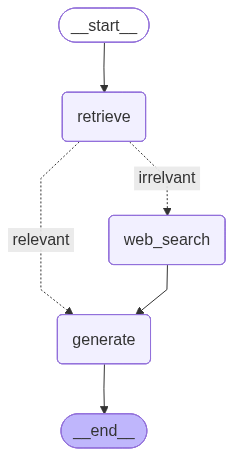

In [13]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
initial_state = {'query': '연봉 5천만원 거주자의 소득세는 얼마인가요?'}
graph.invoke(initial_state)

web search results == [{'title': '연봉 5000만원에 대한 소득세가 다르게 계산되는 ... - Inflearn | Community Q&A', 'url': 'https://www.inflearn.com/community/questions/1653610/%EC%97%B0%EB%B4%89-5000%EB%A7%8C%EC%9B%90%EC%97%90-%EB%8C%80%ED%95%9C-%EC%86%8C%EB%93%9D%EC%84%B8%EA%B0%80-%EB%8B%A4%EB%A5%B4%EA%B2%8C-%EA%B3%84%EC%82%B0%EB%90%98%EB%8A%94-%EB%AC%B8%EC%A0%9C?focusComment=433244', 'content': '4강까지 강의를 다 들었습니다.  \n하지만 연봉 5천만원인 거주자의 소득세는? 이라는 쿼리를 날릴경우 답변이 624만원이 나오지 않고 다양한 값이 나오고 있는것을 확인했습니다.  \n  \nupstage model을 사용하고 pinecone vector store 를 사용하고 있으며 dictionary chain 까지 구성해서 직장인 -> 거주자로 바꾸는것 까지 적용해서 invoke 를 실행했습니다.  \n  \n직접 테스트한 예시로는   \n\'query\': 연봉 5천만원인 거주자의 소득세는 얼마인가요? 소득구간별 세율의 예시를 보여주면서 설명해줘,  \n\'result\': \'연봉 5천만원인 직장인의 소득세는 550만원입니다. 소득구간별 세율에 따라 계산하면, 5천만원 이하의 과세표준에는 15%의 세율이 적용되어 84만원 + (1,400만원을 초과하는 금액의 15%) = 550만원이 소득세로 산출됩니다.\'},  \n  \n{\'query\': \'연봉 5천만원인 직장인의 소득세는 얼마인가요?\', \'result\': \'연봉 5천만원인 직장인의 소득세는 550만원입니다. 이는 종합소득 과세표준 5,000만원 이하 구간에 해당하는 세율을 적용하여 계산한 금액입니다.\',  \n  

{'query': '연봉 5천만원 거주자의 소득세는 얼마인가요?',
 'context': [{'title': '연봉 5000만원에 대한 소득세가 다르게 계산되는 ... - Inflearn | Community Q&A',
   'url': 'https://www.inflearn.com/community/questions/1653610/%EC%97%B0%EB%B4%89-5000%EB%A7%8C%EC%9B%90%EC%97%90-%EB%8C%80%ED%95%9C-%EC%86%8C%EB%93%9D%EC%84%B8%EA%B0%80-%EB%8B%A4%EB%A5%B4%EA%B2%8C-%EA%B3%84%EC%82%B0%EB%90%98%EB%8A%94-%EB%AC%B8%EC%A0%9C?focusComment=433244',
   'content': '4강까지 강의를 다 들었습니다.  \n하지만 연봉 5천만원인 거주자의 소득세는? 이라는 쿼리를 날릴경우 답변이 624만원이 나오지 않고 다양한 값이 나오고 있는것을 확인했습니다.  \n  \nupstage model을 사용하고 pinecone vector store 를 사용하고 있으며 dictionary chain 까지 구성해서 직장인 -> 거주자로 바꾸는것 까지 적용해서 invoke 를 실행했습니다.  \n  \n직접 테스트한 예시로는   \n\'query\': 연봉 5천만원인 거주자의 소득세는 얼마인가요? 소득구간별 세율의 예시를 보여주면서 설명해줘,  \n\'result\': \'연봉 5천만원인 직장인의 소득세는 550만원입니다. 소득구간별 세율에 따라 계산하면, 5천만원 이하의 과세표준에는 15%의 세율이 적용되어 84만원 + (1,400만원을 초과하는 금액의 15%) = 550만원이 소득세로 산출됩니다.\'},  \n  \n{\'query\': \'연봉 5천만원인 직장인의 소득세는 얼마인가요?\', \'result\': \'연봉 5천만원인 직장인의 소득세는 550만원입니다. 이는 종합소득 과세표준 5,000만원 이하 구간에

In [15]:
initial_state = {'query': '역삼역 맛집을 추천해주세요'}
graph.invoke(initial_state)

web search results == [{'title': '역삼역 맛집 베스트10 추천 2024 플레이스 맛집', 'url': 'https://jdblue2022.tistory.com/entry/%EC%97%AD%EC%82%BC%EC%97%AD-%EB%A7%9B%EC%A7%91-%EB%B2%A0%EC%8A%A4%ED%8A%B810', 'content': '\\ 양대 포털에 고르게 노출된 곳 우대\n\n\\ 가성비 좋은 음식점 우대(신규 음식점 제외)\n\n\\ 생활의 달인·식객 허영만·수요미식회 우대\n\n\\ 네이버 어뷰징 업체 제외\n\n\\ 구글 평점 높은 곳 우대\n\n\\ 지역 카페 제외\n\n### 1. 지아니스나폴리 본점(화덕피자 맛집)\n\n지아니스나폴리 역삼 본점 플레이스\n\n지아니스나폴리 역삼 본점 플레이스(구글 평점 4.3)\n\n#### 매장 소개\n\n가장 먼저 소개해드릴 역삼역 맛집은 역삼역 7번 출구 근처에 위치하고 있는 이탈리아 레스토랑 지아니스나폴리 역삼 본점입니다. 이태리 베수비오 화산석으로 만든 화덕에 구워낸 정통 나폴리 화덕피자를 드실 수 있는 역삼역 화덕피자 맛집인데요. 오너 셰프가 운영하는 레스토랑으로 고도 600미터 산간지대에서 생산되는 100년 전통 이태리 치즈와 핏제리아 전통방식의 도우로 만든 화덕피자가 유명한 역삼역 로컬 맛집입니다.\n\n#### 메뉴 소개\n\n- 주빠 디 꼬제 봉골레 15,900원\n\n- 가지 카포나타와 부라타 21,000원\n\n- 마르게리타 23,000원\n\n- 콰트로 스타지오네 28,000원\n\n지아니스나폴리 메뉴 이미지\n\n지아니스나폴리 메뉴 이미지\n\n#### 매장 위치\n\n### 2. 이도곰탕 본점(수요미식회)\n\n역삼역 이도곰탕 플레이스\n\n역삼역 이도곰탕 플레이스(구글 평점 4.2)\n\n#### 매장 소개 [...] 역삼역 옛날농장 플레이스\n\n역삼역 옛날농장 플레이스(구글 평점 4.0)\n\n#### 매장 소개\n\n이어지는 역삼역 맛집은 역삼역 8번 출구

{'query': '역삼역 맛집을 추천해주세요',
 'context': [{'title': '역삼역 맛집 베스트10 추천 2024 플레이스 맛집',
   'url': 'https://jdblue2022.tistory.com/entry/%EC%97%AD%EC%82%BC%EC%97%AD-%EB%A7%9B%EC%A7%91-%EB%B2%A0%EC%8A%A4%ED%8A%B810',
   'content': '\\ 양대 포털에 고르게 노출된 곳 우대\n\n\\ 가성비 좋은 음식점 우대(신규 음식점 제외)\n\n\\ 생활의 달인·식객 허영만·수요미식회 우대\n\n\\ 네이버 어뷰징 업체 제외\n\n\\ 구글 평점 높은 곳 우대\n\n\\ 지역 카페 제외\n\n### 1. 지아니스나폴리 본점(화덕피자 맛집)\n\n지아니스나폴리 역삼 본점 플레이스\n\n지아니스나폴리 역삼 본점 플레이스(구글 평점 4.3)\n\n#### 매장 소개\n\n가장 먼저 소개해드릴 역삼역 맛집은 역삼역 7번 출구 근처에 위치하고 있는 이탈리아 레스토랑 지아니스나폴리 역삼 본점입니다. 이태리 베수비오 화산석으로 만든 화덕에 구워낸 정통 나폴리 화덕피자를 드실 수 있는 역삼역 화덕피자 맛집인데요. 오너 셰프가 운영하는 레스토랑으로 고도 600미터 산간지대에서 생산되는 100년 전통 이태리 치즈와 핏제리아 전통방식의 도우로 만든 화덕피자가 유명한 역삼역 로컬 맛집입니다.\n\n#### 메뉴 소개\n\n- 주빠 디 꼬제 봉골레 15,900원\n\n- 가지 카포나타와 부라타 21,000원\n\n- 마르게리타 23,000원\n\n- 콰트로 스타지오네 28,000원\n\n지아니스나폴리 메뉴 이미지\n\n지아니스나폴리 메뉴 이미지\n\n#### 매장 위치\n\n### 2. 이도곰탕 본점(수요미식회)\n\n역삼역 이도곰탕 플레이스\n\n역삼역 이도곰탕 플레이스(구글 평점 4.2)\n\n#### 매장 소개 [...] 역삼역 옛날농장 플레이스\n\n역삼역 옛날농장 플레이스(구글 평점 4.0)\n\n#### 매장 소개\n